In [1]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from PIL import Image

from src.data.dataset import ScanpathDataset
from src.data.dataloader import make_dataloader

PARQUET_PATH = (
    "/mnt/vast-nhr/projects/nim00018/datasets/scanpath_parquet"
    "/2026_03_03_20_41_11_268d00ae/scanpaths/merged.parquet"
)

IMAGENET_ROOT = "/mnt/vast-nhr/projects/nim00018/datasets/ImageNet"
DEBUG_PARQUET = ROOT / "data/debug_scanpaths.parquet"

In [2]:
pf = pq.ParquetFile(PARQUET_PATH)

print("num_row_groups:", pf.num_row_groups)
print("schema:")
print(pf.schema)

table = pf.read_row_group(0, columns=["image_path", "locations"])
table = table.slice(0, min(5000, table.num_rows))
df = table.to_pandas()

print("shape:", df.shape)
print("columns:", df.columns.tolist())
print("unique images:", df["image_path"].nunique())
print("rows per image:")
print(df["image_path"].value_counts().describe())

num_row_groups: 410
schema:
required group field_id=-1 schema {
  optional binary field_id=-1 image_path (String);
  optional int32 field_id=-1 epoch (Int(bitWidth=16, isSigned=true));
  optional group field_id=-1 locations (List) {
    repeated group field_id=-1 list {
      optional float field_id=-1 element;
    }
  }
  optional group field_id=-1 log_pis (List) {
    repeated group field_id=-1 list {
      optional float field_id=-1 element;
    }
  }
}

shape: (5000, 2)
columns: ['image_path', 'locations']
unique images: 313
rows per image:
count    313.000000
mean      15.974441
std        0.452187
min        8.000000
25%       16.000000
50%       16.000000
75%       16.000000
max       16.000000
Name: count, dtype: float64


In [3]:
def get_fixations(row):
    return np.asarray(row["locations"]).reshape(-1, 2)

scanpath_lengths = df["locations"].apply(lambda x: len(np.asarray(x)) // 2)

print("number of scanpaths:", len(df))
print("number of unique images:", df["image_path"].nunique())
print("scanpath lengths:")
print(scanpath_lengths.describe())

print("rows per image:")
print(df.groupby("image_path").size().describe())

number of scanpaths: 5000
number of unique images: 313
scanpath lengths:
count    5000.0
mean       16.0
std         0.0
min        16.0
25%        16.0
50%        16.0
75%        16.0
max        16.0
Name: locations, dtype: float64
rows per image:
count    313.000000
mean      15.974441
std        0.452187
min        8.000000
25%       16.000000
50%       16.000000
75%       16.000000
max       16.000000
dtype: float64


all fixations shape: (80000, 2)
x min/max: -0.9983 0.9995
y min/max: -0.9925 0.9999


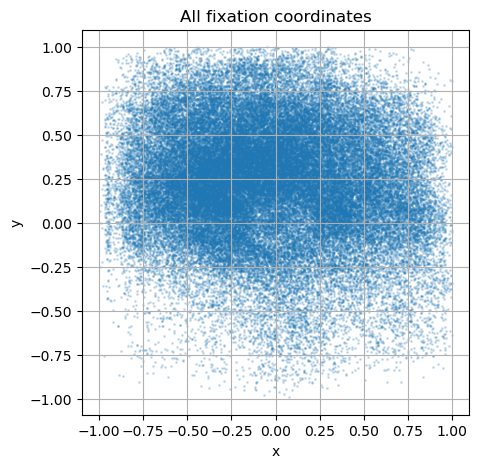

In [6]:
all_fix = np.concatenate([get_fixations(row) for _, row in df.iterrows()], axis=0)

print("all fixations shape:", all_fix.shape)
print("x min/max:", all_fix[:, 0].min(), all_fix[:, 0].max())
print("y min/max:", all_fix[:, 1].min(), all_fix[:, 1].max())

plt.figure(figsize=(5, 5))
plt.scatter(all_fix[:, 0], all_fix[:, 1], s=1, alpha=0.2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("All fixation coordinates")
plt.grid(True)
plt.show()

first fixation unique values: [[0. 0.]]
number unique first fixations: 1


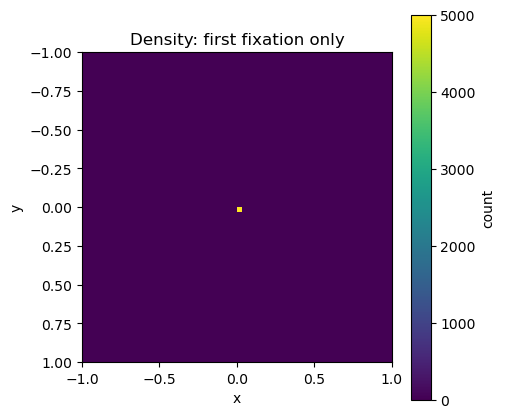

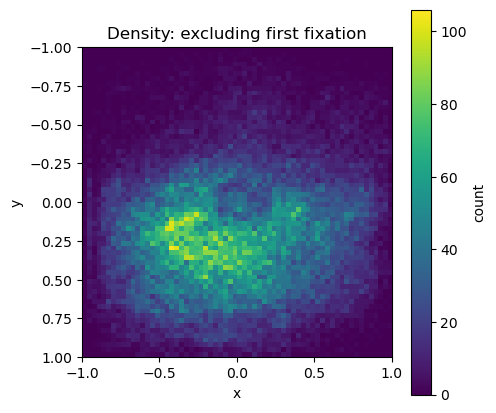

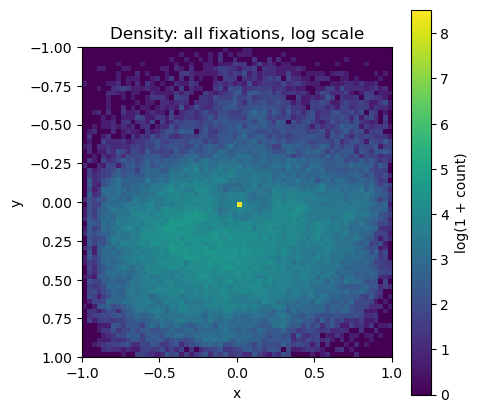

In [11]:
fix_by_step = np.stack([get_fixations(row) for _, row in df.iterrows()], axis=0)
# shape: (num_scanpaths, 16, 2)

first_fix = fix_by_step[:, 0, :]
without_first = fix_by_step[:, 1:, :].reshape(-1, 2)
all_fix = fix_by_step.reshape(-1, 2)

print("first fixation unique values:", np.unique(first_fix, axis=0)[:10])
print("number unique first fixations:", len(np.unique(first_fix, axis=0)))

def plot_density(fixations, title, bins=64, log=False):
    H, _, _ = np.histogram2d(
        fixations[:, 1],  # y
        fixations[:, 0],  # x
        bins=bins,
        range=[[-1, 1], [-1, 1]],
    )

    if log:
        H_plot = np.log1p(H)
        label = "log(1 + count)"
    else:
        H_plot = H
        label = "count"

    plt.figure(figsize=(5, 5))
    plt.imshow(H_plot, origin="upper", extent=[-1, 1, 1, -1])
    plt.colorbar(label=label)
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

plot_density(first_fix, "Density: first fixation only")
plot_density(without_first, "Density: excluding first fixation")
plot_density(all_fix, "Density: all fixations, log scale", log=True)

(5000, 16, 2)


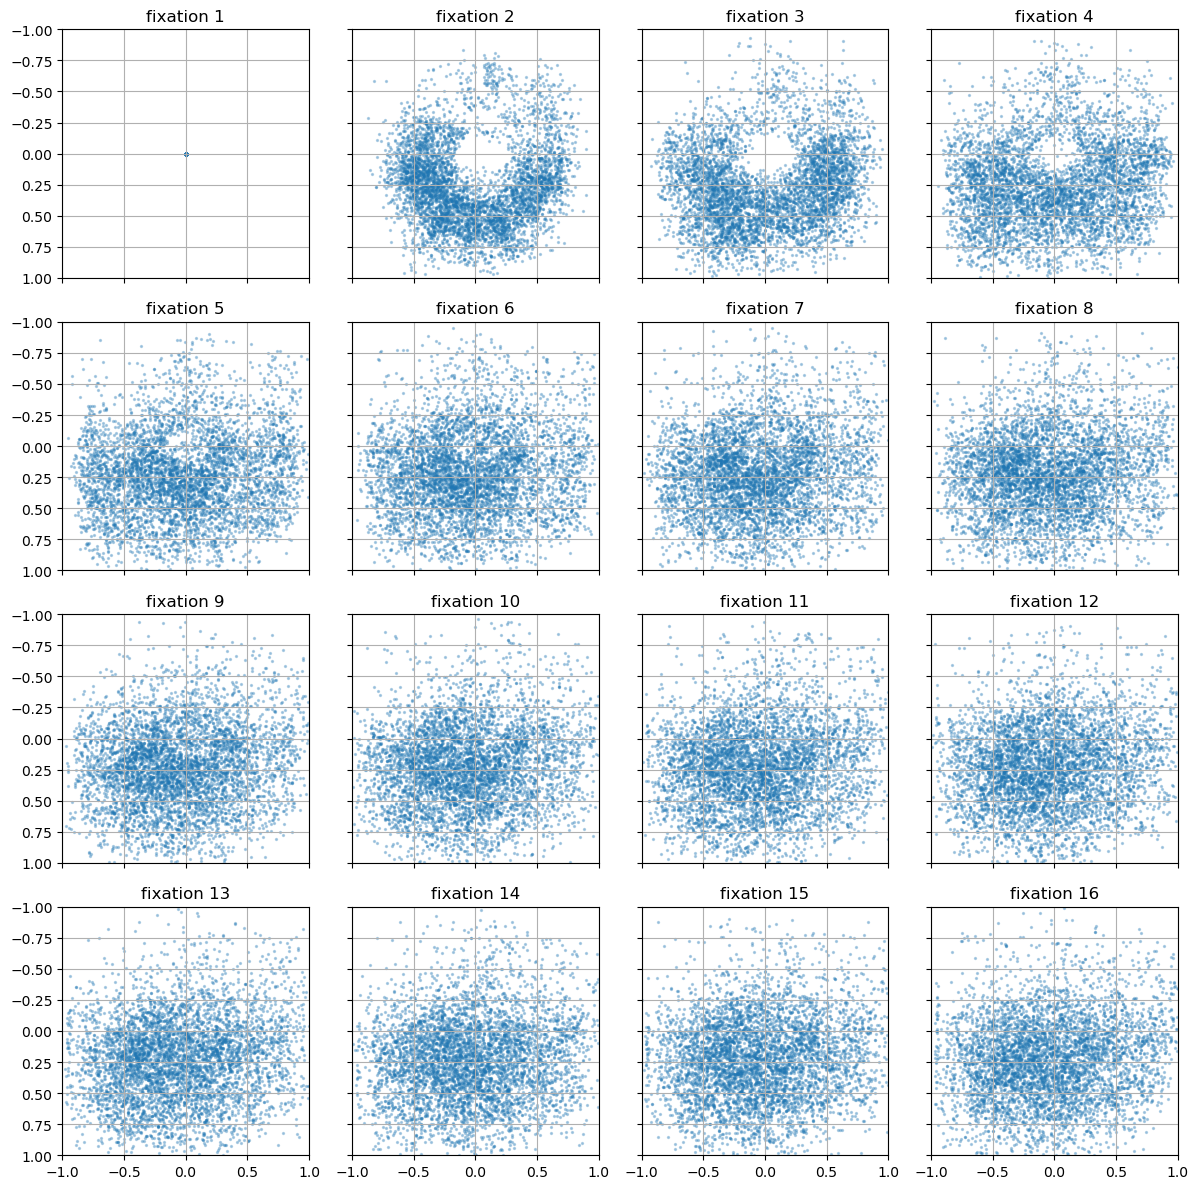

In [12]:
fix_by_step = np.stack([get_fixations(row) for _, row in df.iterrows()], axis=0)
# shape: (num_scanpaths, 16, 2)

print(fix_by_step.shape)

fig, axes = plt.subplots(4, 4, figsize=(12, 12), sharex=True, sharey=True)

for t, ax in enumerate(axes.flat):
    xy = fix_by_step[:, t, :]
    ax.scatter(xy[:, 0], xy[:, 1], s=2, alpha=0.3)
    ax.set_title(f"fixation {t+1}")
    ax.set_xlim(-1, 1)
    ax.set_ylim(1, -1)
    ax.grid(True)

plt.tight_layout()
plt.show()

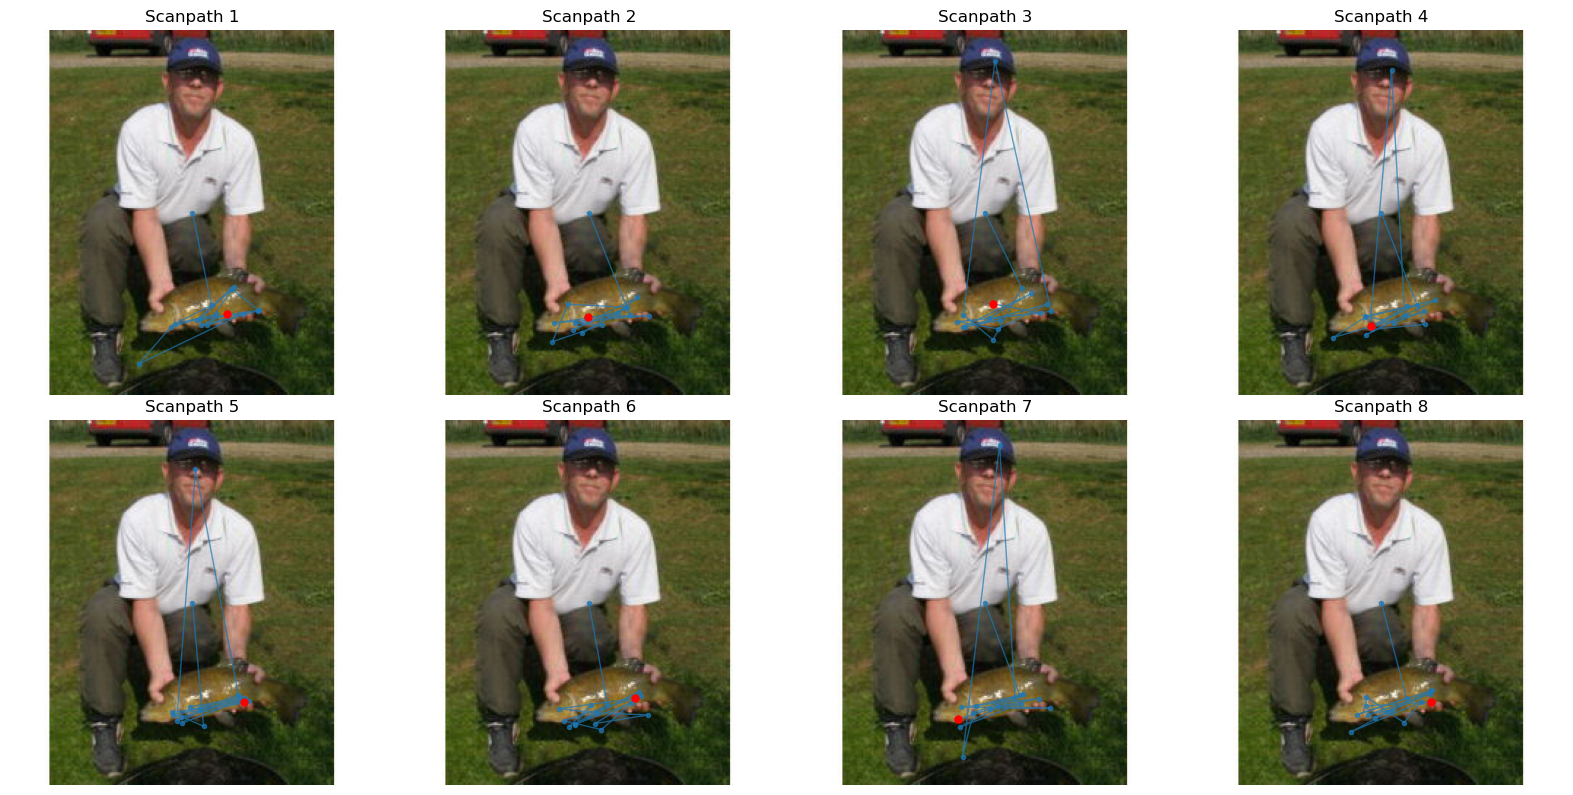

In [ ]:
def resolve_image_path(path):
    return path.replace("./data/ImageNet", IMAGENET_ROOT)

image_path = df.iloc[0]["image_path"]
same_image = df[df["image_path"] == image_path]

img = Image.open(resolve_image_path(image_path)).convert("RGB")

W, H_img = img.size

num_scanpaths = len(same_image.head(8))
ncols = 4
nrows = (num_scanpaths + ncols - 1) // ncols  # Ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows))
axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes

for i, (_, row) in enumerate(same_image.head(8).iterrows()):
    ax = axes[i]
    ax.imshow(img)
    ax.set_title(f"Scanpath {i+1}")
    ax.axis("off")
    
    fix = get_fixations(row)
    xs = (fix[:, 0] + 1) / 2 * (W - 1)
    ys = (fix[:, 1] + 1) / 2 * (H_img - 1)
    ax.plot(xs, ys, marker="o", linewidth=1, markersize=3, alpha=0.7)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [21]:
ds = ScanpathDataset(
    split="train",
    max_images=5,
    heatmap_sigma=2.0,
    heatmap_size=64,
    parquet_path=str(DEBUG_PARQUET),
)

sample = ds[0]

for k, v in sample.items():
    if hasattr(v, "shape"):
        print(k, tuple(v.shape), v.dtype)
    else:
        print(k, v)

print("prefix_len:", sample["prefix_len"])
print("target_xy:", sample["target_xy"])
print("heatmap sum:", sample["heatmap"].sum().item())

image (3, 224, 224) torch.float32
prefix (15, 2) torch.float32
prefix_len 2
heatmap (64, 64) torch.float32
target_xy (2,) torch.float32
prefix_len: 2
target_xy: tensor([0.3531, 0.2548])
heatmap sum: 1.0


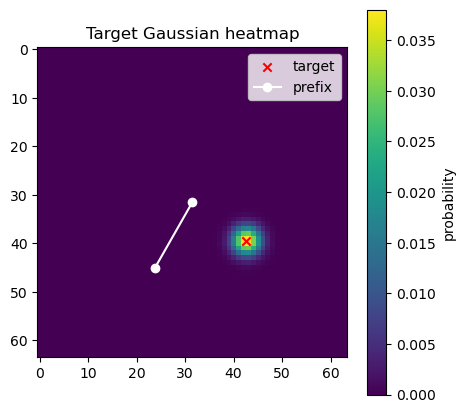

In [22]:
prefix = sample["prefix"].numpy()
prefix_len = sample["prefix_len"]
target_xy = sample["target_xy"].numpy()
heatmap = sample["heatmap"].numpy()

plt.figure(figsize=(5, 5))
plt.imshow(heatmap, origin="upper")
plt.colorbar(label="probability")
plt.title("Target Gaussian heatmap")

target_px = (target_xy[0] + 1) / 2 * 63
target_py = (target_xy[1] + 1) / 2 * 63
plt.scatter([target_px], [target_py], c="red", marker="x", label="target")

prefix_valid = prefix[:prefix_len]
prefix_px = (prefix_valid[:, 0] + 1) / 2 * 63
prefix_py = (prefix_valid[:, 1] + 1) / 2 * 63
plt.plot(prefix_px, prefix_py, c="white", marker="o", label="prefix")

plt.legend()
plt.show()

In [23]:
loader = make_dataloader(
    split="train",
    batch_size=8,
    num_workers=0,
    max_images=5,
    use_grouped_sampler=False,
    heatmap_sigma=2.0,
    heatmap_size=64,
    parquet_path=str(DEBUG_PARQUET),
)

batch = next(iter(loader))

for k, v in batch.items():
    print(k, tuple(v.shape), v.dtype)

print("heatmap sums:", batch["heatmap"].sum(dim=(-1, -2)))
print("prefix lengths:", batch["prefix_len"])

image (8, 3, 224, 224) torch.float32
prefix (8, 15, 2) torch.float32
prefix_len (8,) torch.int64
heatmap (8, 64, 64) torch.float32
target_xy (8, 2) torch.float32
heatmap sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
prefix lengths: tensor([ 2, 12, 10,  7,  7, 13,  2, 11])


/mnt/vast-nhr/home/tomcosmo.fischer/u27846/miniforge3/envs/praktikum/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
